In [3]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [3]:
df=pd.read_csv("Ice_cream selling data.csv")

In [4]:
df.columns

Index(['Temperature (°C)', 'Ice Cream Sales (units)'], dtype='str')

<Axes: xlabel='Ice Cream Sales (units)', ylabel='Count'>

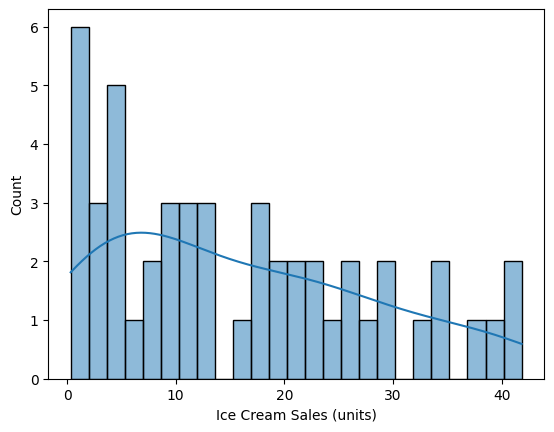

In [6]:
sns.histplot(data=df,x="Ice Cream Sales (units)",kde=True,bins=25)

<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

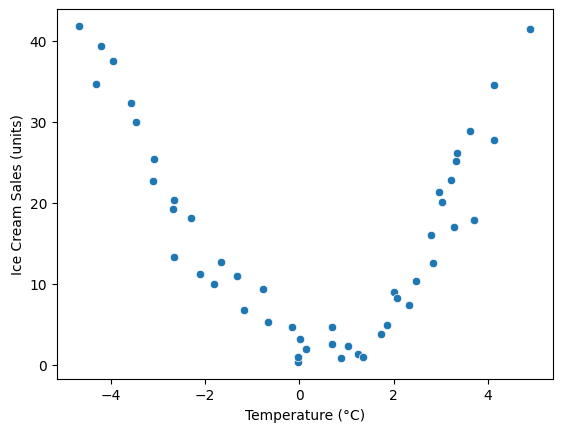

In [8]:
sns.scatterplot(data=df,y="Ice Cream Sales (units)",x="Temperature (°C)")

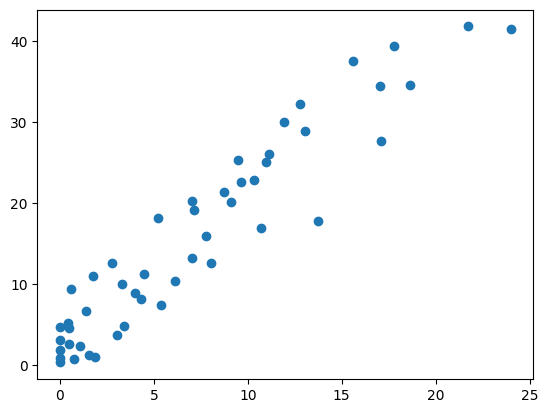

In [10]:
plt.scatter(x=df["Temperature (°C)"]*df["Temperature (°C)"],y=df["Ice Cream Sales (units)"])

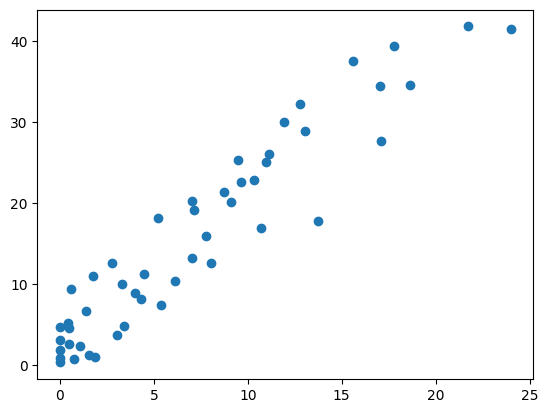

In [17]:
plt.scatter(x=df["Temperature (°C)"]*df["Temperature (°C)"],y=df["Ice Cream Sales (units)"])

In [18]:
x=df[["Temperature (°C)"]]
y=df["Ice Cream Sales (units)"]

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
print(x_train_poly)
x_test_poly=poly.transform(x_test)
print(x_test_poly)

[[ 1.00000000e+00 -2.11186969e+00  4.45999359e+00]
 [ 1.00000000e+00 -3.57855372e+00  1.28060467e+01]
 [ 1.00000000e+00  2.31859124e+00  5.37586534e+00]
 [ 1.00000000e+00 -2.67246083e+00  7.14204687e+00]
 [ 1.00000000e+00 -3.94966109e+00  1.55998227e+01]
 [ 1.00000000e+00 -3.10844012e+00  9.66239999e+00]
 [ 1.00000000e+00  3.21136614e+00  1.03128725e+01]
 [ 1.00000000e+00  3.27004407e+00  1.06931882e+01]
 [ 1.00000000e+00  4.13086796e+00  1.70640701e+01]
 [ 1.00000000e+00 -1.32637898e+00  1.75928121e+00]
 [ 1.00000000e+00 -2.65228679e+00  7.03462523e+00]
 [ 1.00000000e+00 -1.17312327e+00  1.37621820e+00]
 [ 1.00000000e+00  6.88780908e-01  4.74419139e-01]
 [ 1.00000000e+00  2.07510060e+00  4.30604249e+00]
 [ 1.00000000e+00  1.74000001e+00  3.02760004e+00]
 [ 1.00000000e+00 -4.66226268e+00  2.17366933e+01]
 [ 1.00000000e+00  3.33593241e+00  1.11284451e+01]
 [ 1.00000000e+00  1.99931037e+00  3.99724195e+00]
 [ 1.00000000e+00 -3.45571170e+00  1.19419433e+01]
 [ 1.00000000e+00  1.35981267e+

In [26]:
model=LinearRegression()
model.fit(x_train_poly,y_train)

y_pred = model.predict(x_test_poly)
print(model.coef_)
print(model.intercept_)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

[ 0.         -0.70641926  1.87145125]
2.7683058295738583
3.2299819836597274
14.878796440981484
0.843055137193884


In [5]:
df=pd.read_csv("Fish.csv")
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [29]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='str')

In [6]:
# x=[["Species","Width","Height","Length1","Length2","Length3"]]
x=df.drop(["Species","Weight"],axis=1)
y=df["Weight"]
r2=[]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.preprocessing import PolynomialFeatures
for i in range(2,9):
    poly=PolynomialFeatures(degree=i)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.fit_transform(x_test)
    model = LinearRegression()
    model.fit(x_train_poly,y_train)
    y_train_pred=model.predict(x_test_poly)
    r2.append(r2_score(y_test,y_train_pred))
    print(r2_score(y_test,y_pred))
plt.plot(range(2,9),r2)

NameError: name 'y_pred' is not defined